<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/NLP_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:

import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # Add this line
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
import pandas as pd

comments = [
    "The product quality is excellent.",
    "I am not happy with this purchase.",
    "Delivery was faster than expected.",
    "The item arrived with scratches.",
    "Very comfortable and easy to use.",
    "Customer service was extremely helpful.",
    "The product stopped working after two days.",
    "Amazing performance for the price.",
    "The packaging was neat and secure.",
    "I would not buy this again.",
    "The design is sleek and attractive.",
    "Battery backup is disappointing.",
    "This exceeded all my expectations.",
    "The instructions were easy to follow.",
    "The material feels very cheap.",
    "Excellent value for money.",
    "The website checkout process was smooth.",
    "I received a defective item.",
    "Very satisfied with my order.",
    "The color looks different from the picture.",
    "Installation took only a few minutes.",
    "The app crashes frequently.",
    "Fantastic customer support experience.",
    "The delivery was delayed without notice.",
    "Highly impressed with the product quality.",
    "The screen is bright and clear.",
    "Poor sound quality.",
    "Everything works perfectly.",
    "The buttons are difficult to press.",
    "I highly recommend this product.",
    "The size was smaller than expected.",
    "The performance is outstanding.",
    "The charger stopped working.",
    "Very lightweight and portable.",
    "The refund was processed quickly.",
    "I regret buying this item.",
    "The camera captures sharp images.",
    "The software is full of bugs.",
    "Excellent build quality.",
    "Not worth the price I paid.",
    "The product arrived earlier than expected.",
    "I am completely satisfied with the purchase.",
    "The support team never responded.",
    "Very stylish and modern design.",
    "The keyboard is comfortable to type on.",
    "The speaker volume is too low.",
    "Five stars for excellent service.",
    "The product description was misleading.",
    "I would definitely recommend it to my friends.",
    "Overall, it was a great shopping experience."
]

df = pd.DataFrame(comments, columns=["Comment"])

print(df)

                                           Comment
0                The product quality is excellent.
1               I am not happy with this purchase.
2               Delivery was faster than expected.
3                 The item arrived with scratches.
4                Very comfortable and easy to use.
5          Customer service was extremely helpful.
6      The product stopped working after two days.
7               Amazing performance for the price.
8               The packaging was neat and secure.
9                      I would not buy this again.
10             The design is sleek and attractive.
11                Battery backup is disappointing.
12              This exceeded all my expectations.
13           The instructions were easy to follow.
14                  The material feels very cheap.
15                      Excellent value for money.
16        The website checkout process was smooth.
17                    I received a defective item.
18                   Very satis

In [44]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["Comment"].apply(clean_text)

print(df)


                                           Comment  \
0                The product quality is excellent.   
1               I am not happy with this purchase.   
2               Delivery was faster than expected.   
3                 The item arrived with scratches.   
4                Very comfortable and easy to use.   
5          Customer service was extremely helpful.   
6      The product stopped working after two days.   
7               Amazing performance for the price.   
8               The packaging was neat and secure.   
9                      I would not buy this again.   
10             The design is sleek and attractive.   
11                Battery backup is disappointing.   
12              This exceeded all my expectations.   
13           The instructions were easy to follow.   
14                  The material feels very cheap.   
15                      Excellent value for money.   
16        The website checkout process was smooth.   
17                    I rece

In [45]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(sentiment)

print(df)

                                           Comment  \
0                The product quality is excellent.   
1               I am not happy with this purchase.   
2               Delivery was faster than expected.   
3                 The item arrived with scratches.   
4                Very comfortable and easy to use.   
5          Customer service was extremely helpful.   
6      The product stopped working after two days.   
7               Amazing performance for the price.   
8               The packaging was neat and secure.   
9                      I would not buy this again.   
10             The design is sleek and attractive.   
11                Battery backup is disappointing.   
12              This exceeded all my expectations.   
13           The instructions were easy to follow.   
14                  The material feels very cheap.   
15                      Excellent value for money.   
16        The website checkout process was smooth.   
17                    I rece

In [46]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    27
Neutral     16
Negative     7
Name: count, dtype: int64


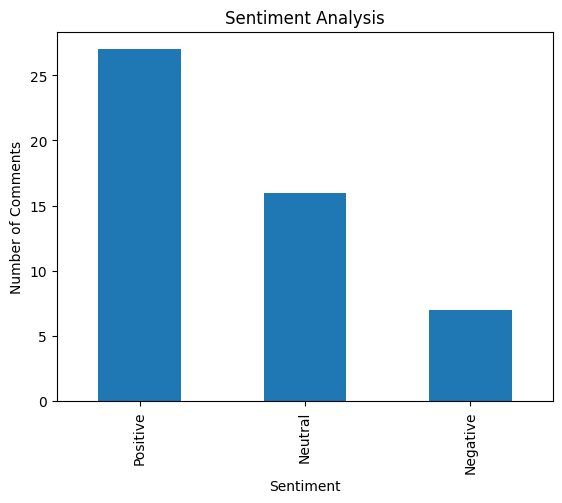

In [47]:
df["Sentiment"].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

In [48]:
text = " ".join(df["Cleaned"])

print(text)

product quality excellent happy purchase delivery faster expected item arrived scratches comfortable easy use customer service extremely helpful product stopped working two days amazing performance price packaging neat secure would buy design sleek attractive battery backup disappointing exceeded expectations instructions easy follow material feels cheap excellent value money website checkout process smooth received defective item satisfied order color looks different picture installation took minutes app crashes frequently fantastic customer support experience delivery delayed without notice highly impressed product quality screen bright clear poor sound quality everything works perfectly buttons difficult press highly recommend product size smaller expected performance outstanding charger stopped working lightweight portable refund processed quickly regret buying item camera captures sharp images software full bugs excellent build quality worth price paid product arrived earlier expe

In [49]:
from collections import Counter

words = text.split()

counter = Counter(words)

print(counter.most_common(10))

[('product', 6), ('quality', 4), ('excellent', 4), ('expected', 3), ('item', 3), ('purchase', 2), ('delivery', 2), ('arrived', 2), ('comfortable', 2), ('easy', 2)]


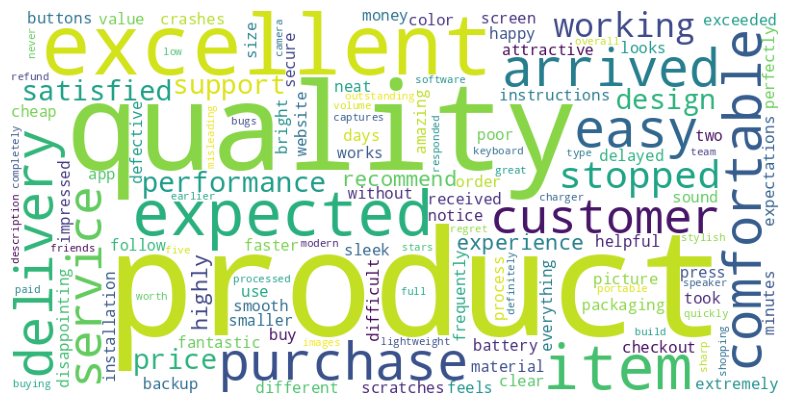

In [50]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()